Waiting for Godot start
Started
Notebook configured for 4 current drones and 6 maximum drones


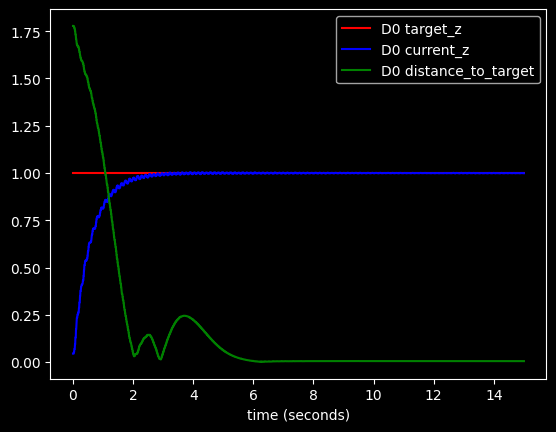

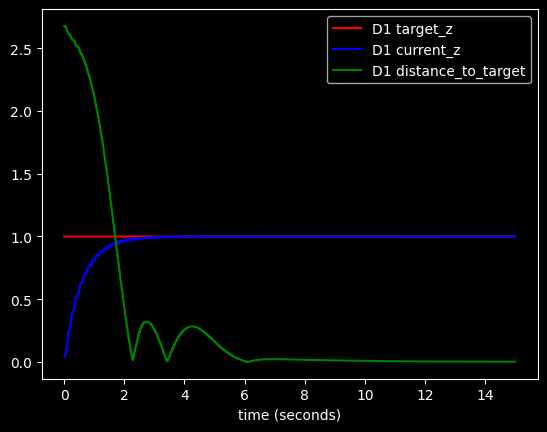

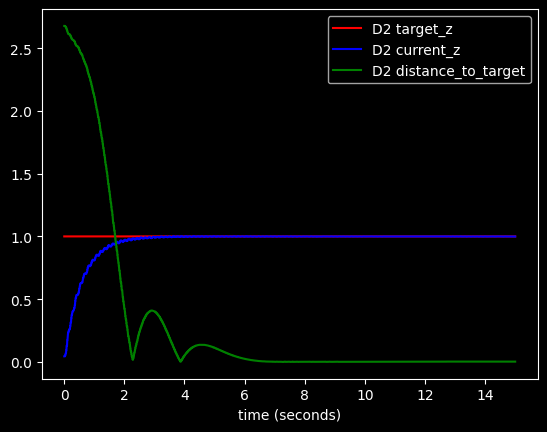

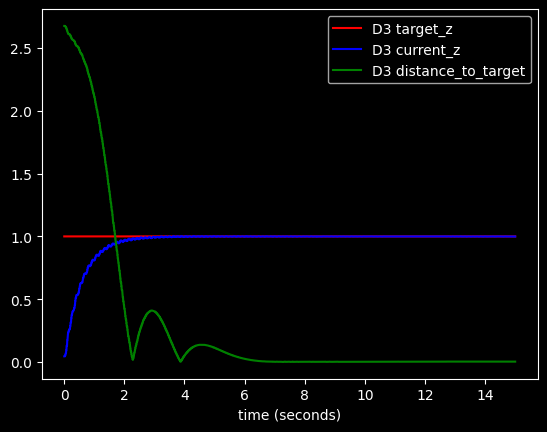

Skipped 2 zero-delta tick(s)
Done


In [ ]:
import sys
sys.path.append("../../")

import math

from lib.data.dataplot import *
from lib.dds.dds import *
from lib.utils.time import *
from lib.system.controllers import *


MAX_DRONES = 6
CURRENT_DRONES = 4
HOVER_ALTITUDE = 1.0
FORMATION_SPACING = 1.0
RUN_SECONDS = 15
MIN_DELTA_T = 0.0001

STATE_NAMES = ["X", "Y", "Z", "TX", "TY", "TZ", "VX", "VY", "VZ", "WX", "WY", "WZ"]
FORCE_NAMES = ["f1", "f2", "f3", "f4"]


def validate_startup_settings():
    if MAX_DRONES <= 0:
        raise ValueError("MAX_DRONES must be positive")
    if CURRENT_DRONES < 0 or CURRENT_DRONES > MAX_DRONES:
        raise ValueError("CURRENT_DRONES must be between 0 and MAX_DRONES")


def topic(drone_id, name):
    return f"D{drone_id}_{name}"


def hover_target_for(drone_id, drone_count, spacing=FORMATION_SPACING):
    # Match the deterministic line of spawn positions used by SwarmManager.
    centered_index = drone_id - ((drone_count - 1) * 0.5)
    return {
        "x": 0.0,
        "y": centered_index * spacing,
        "z": HOVER_ALTITUDE,
    }


def safe_value(value, default=0.0):
    return default if value is None else value


def distance_to_target(state, target):
    dx = target["x"] - state["x"]
    dy = target["y"] - state["y"]
    dz = target["z"] - state["z"]
    return math.sqrt((dx * dx) + (dy * dy) + (dz * dz))


class Multirotor:

    def __init__(self, x_target=0.0, y_target=0.0, z_target=HOVER_ALTITUDE):
        self.vz_control = PID_Controller(5.0, 10.0, 0.0, 5)
        self.z_control = PID_Controller(2.0, 0.0, 0.0, 2)

        self.w_roll_control = PID_Controller(0.75, 0.3, 0.0075, 2)
        self.roll_control = PID_Controller(1.0, 0.0, 0.0, 2)

        self.w_pitch_control = PID_Controller(0.75, 0.3, 0.0075, 2)
        self.pitch_control = PID_Controller(1.0, 0.0, 0.0, 2)

        self.vy_control = PID_Controller(0.4, 0.01, 0.25, math.radians(30))
        self.y_control = PID_Controller(1.0, 0.0, 0.0, 2.0)

        self.vx_control = PID_Controller(0.4, 0.01, 0.25, math.radians(30))
        self.x_control = PID_Controller(1.0, 0.0, 0.0, 2.0)

        self.z_target = z_target
        self.x_target = x_target
        self.y_target = y_target

        self.vz_target = 0.0
        self.vx_target = 0.0
        self.vy_target = 0.0

    def set_target(self, target):
        self.x_target = target["x"]
        self.y_target = target["y"]
        self.z_target = target["z"]

    def evaluate(self, delta_t, z, vz, x, vx, y, vy, roll, roll_rate, pitch, pitch_rate):
        # The output order matches the four propeller topics D{i}_f1..D{i}_f4.
        self.vz_target = self.z_control.evaluate(delta_t, self.z_target - z)
        f = self.vz_control.evaluate(delta_t, self.vz_target - vz)

        self.vy_target = self.y_control.evaluate(delta_t, self.y_target - y)
        self.roll_target = -self.vy_control.evaluate(delta_t, self.vy_target - vy)

        self.vx_target = self.x_control.evaluate(delta_t, self.x_target - x)
        self.pitch_target = self.vx_control.evaluate(delta_t, self.vx_target - vx)

        self.roll_rate_target = self.roll_control.evaluate(delta_t, self.roll_target - roll)
        roll_command = self.w_roll_control.evaluate(delta_t, self.roll_rate_target - roll_rate)

        self.pitch_rate_target = self.pitch_control.evaluate(delta_t, self.pitch_target - pitch)
        pitch_command = self.w_pitch_control.evaluate(delta_t, self.pitch_rate_target - pitch_rate)

        return (
            f + roll_command - pitch_command,
            f - roll_command - pitch_command,
            f - roll_command + pitch_command,
            f + roll_command + pitch_command,
        )


def subscribe_topics_for(max_drones):
    topics = ["start", "tick", "drone_count"]
    for drone_id in range(max_drones):
        topics.append(topic(drone_id, "active"))
        for state_name in STATE_NAMES:
            topics.append(topic(drone_id, state_name))
    return topics


def read_drone_count(dds):
    raw_count = int(safe_value(dds.read("drone_count"), CURRENT_DRONES))
    return max(0, min(raw_count, MAX_DRONES))


def is_drone_active(dds, drone_id):
    return int(safe_value(dds.read(topic(drone_id, "active")), 1)) == 1


def read_drone_state(dds, drone_id):
    return {
        "x": safe_value(dds.read(topic(drone_id, "X"))),
        "y": safe_value(dds.read(topic(drone_id, "Y"))),
        "z": safe_value(dds.read(topic(drone_id, "Z"))),
        "roll": safe_value(dds.read(topic(drone_id, "TX"))),
        "pitch": safe_value(dds.read(topic(drone_id, "TY"))),
        "vx": safe_value(dds.read(topic(drone_id, "VX"))),
        "vy": safe_value(dds.read(topic(drone_id, "VY"))),
        "vz": safe_value(dds.read(topic(drone_id, "VZ"))),
        "roll_rate": safe_value(dds.read(topic(drone_id, "WX"))),
        "pitch_rate": safe_value(dds.read(topic(drone_id, "WY"))),
    }


def publish_forces(dds, drone_id, forces):
    for force_name, force_value in zip(FORCE_NAMES, forces):
        dds.publish(topic(drone_id, force_name), force_value, DDS.DDS_TYPE_FLOAT)


def stop_all_motors(dds, max_drones):
    for drone_id in range(max_drones):
        publish_forces(dds, drone_id, (0.0, 0.0, 0.0, 0.0))


def create_drone_plotter(drone_id):
    plotter = DataPlotter()
    plotter.set_x("time (seconds)")
    plotter.add_y("target_z", f"D{drone_id} target_z")
    plotter.add_y("current_z", f"D{drone_id} current_z")
    plotter.add_y("distance", f"D{drone_id} distance_to_target")
    return plotter


def append_drone_plot(plotter, current_time, robot, state, target):
    plotter.append_x(current_time)
    plotter.append_y("target_z", robot.z_target)
    plotter.append_y("current_z", state["z"])
    plotter.append_y("distance", distance_to_target(state, target))


validate_startup_settings()

controllers = {}
drone_plotters = {}
active_ids_previous_tick = set()
skipped_zero_delta_ticks = 0

dds = DDS()
dds.start()
dds.subscribe(subscribe_topics_for(MAX_DRONES))

print("Waiting for Godot start")
dds.wait("start")
print("Started")
print(f"Notebook configured for {CURRENT_DRONES} current drones and {MAX_DRONES} maximum drones")

t = Time()
t.start()

try:
    while t.get() < RUN_SECONDS:
        dds.wait("tick")
        delta_t = t.elapsed()
        if delta_t <= MIN_DELTA_T:
            skipped_zero_delta_ticks += 1
            continue

        drone_count = read_drone_count(dds)
        active_ids_this_tick = set()

        for drone_id in range(drone_count):
            if not is_drone_active(dds, drone_id):
                publish_forces(dds, drone_id, (0.0, 0.0, 0.0, 0.0))
                continue

            active_ids_this_tick.add(drone_id)
            if drone_id not in controllers:
                controllers[drone_id] = Multirotor()
            if drone_id not in drone_plotters:
                drone_plotters[drone_id] = create_drone_plotter(drone_id)

            target = hover_target_for(drone_id, drone_count)
            robot = controllers[drone_id]
            robot.set_target(target)

            state = read_drone_state(dds, drone_id)
            forces = robot.evaluate(
                delta_t,
                state["z"], state["vz"],
                state["x"], state["vx"],
                state["y"], state["vy"],
                state["roll"], state["roll_rate"],
                state["pitch"], state["pitch_rate"],
            )
            publish_forces(dds, drone_id, forces)
            append_drone_plot(drone_plotters[drone_id], t.get(), robot, state, target)

        # Future add/remove support: explicitly zero any drone that disappeared.
        for removed_drone_id in active_ids_previous_tick - active_ids_this_tick:
            publish_forces(dds, removed_drone_id, (0.0, 0.0, 0.0, 0.0))

        active_ids_previous_tick = active_ids_this_tick

finally:
    stop_all_motors(dds, MAX_DRONES)
    dds.stop()

for drone_id in sorted(drone_plotters):
    if len(drone_plotters[drone_id].x_data) > 0:
        drone_plotters[drone_id].plot()

if skipped_zero_delta_ticks > 0:
    print(f"Skipped {skipped_zero_delta_ticks} zero-delta tick(s)")

print("Done")
